# Import Required Libraries

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load the Dataset

In [17]:
# Load dataset
data = pd.read_csv("data/real_estate_dataset.csv")

# Show first 5 rows
data.head()

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1,3,3,1967,1,1,48,8.297631,5.935734,602134.816747
1,2,287.678577,1,2,1,1949,0,1,37,6.061466,10.827392,591425.135386
2,3,232.998485,1,3,2,1923,1,0,14,2.911442,6.904599,464478.696880
3,4,199.664621,5,2,2,1918,0,0,17,2.070949,8.284019,583105.655996
4,5,89.004660,4,3,3,1999,1,0,34,1.523278,14.648277,619879.142523


# Select Input and Output

Decided:

Input → Square_Feet

Output → Price 

In [18]:
# Select feature (X) and target (y)
X = data[['Square_Feet']]
y = data['Price']

print("Input Shape:", X.shape)
print("Output Shape:", y.shape)

Input Shape: (500, 1)
Output Shape: (500,)


# X → 2D format (required by sklearn)

# y → target values

# Now, Create and Train the Model

In [19]:
# Create model
model = LinearRegression()

# Train model
model.fit(X, y)

print("Model Training Completed ")

Model Training Completed 


LinearRegression() → creates empty model

fit() → model learns from data

It finds best straight line

# Check Model Coefficients

In [20]:
print("Intercept (b0):", model.intercept_)
print("Slope (b1):", model.coef_[0])

Intercept (b0): 422466.5157033005
Slope (b1): 914.6972187433454


# Equation of line:

Price = b0 + b1 × (Square_Feet)

b0 → starting value

b1 → how much price increases per square foot

Example :

If slope = 1200
It means price increases ₹1200 per square foot.

# Visualize the Regression Line

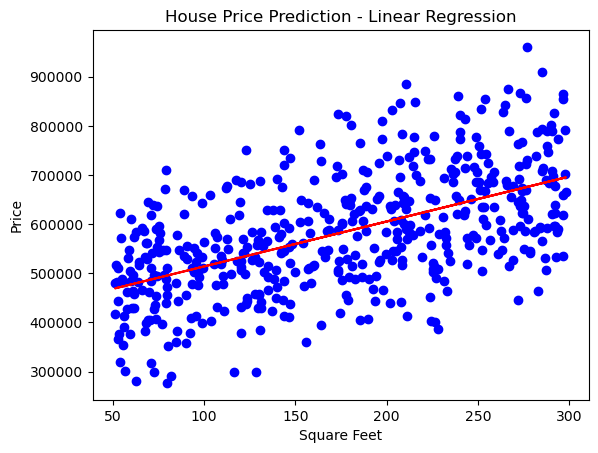

In [21]:
plt.scatter(X, y, color='blue')
plt.plot(X, model.predict(X), color='red')

plt.xlabel("Square Feet")
plt.ylabel("Price")
plt.title("House Price Prediction - Linear Regression")
plt.show()

Blue dots → actual data

Red line → predicted line

Model tries to pass through middle

# Test the Model

In [22]:
# Create a DataFrame with correct column name
new_data = pd.DataFrame({'Square_Feet': [2000]})

# Predict price
predicted_price = model.predict(new_data)

print("Predicted price for 2000 sq.ft house:", predicted_price[0])

Predicted price for 2000 sq.ft house: 2251860.9531899914


# Save the Model

In [23]:
import pickle

# Save the trained model inside model folder
with open("model/house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully ")

Model saved successfully 


pickle → Python tool to save objects

"wb" → write in binary mode

pickle.dump() → saves model into file

# Test the Saved Model

clear the doubt called: can model work after loading from file?

In [25]:
# Load the saved model
with open("model/house_price_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

# Test prediction again
new_data = pd.DataFrame({'Square_Feet': [1800]})
prediction = loaded_model.predict(new_data)

print("Predicted price for 1800 sq.ft house:", prediction[0])

Predicted price for 1800 sq.ft house: 2068921.5094413222


This proves:

Model works without training again
Deployment is possible
Notebook is not required anymore